## NPQ Correction

In [1]:
from smode_import import *

In [2]:
# MVP
mvp = xr.open_dataset('MVP.nc')

# TSG
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

In [43]:
times_dopplerscatt=['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]
time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:55:00', '2023-04-22T23:40:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
]

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_44099/2235581205.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("coolwarm")  # Choose a colormap, e.g., darkblue to gold


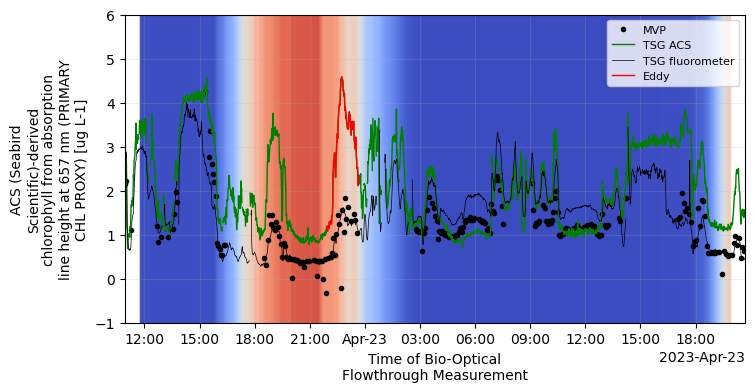

In [45]:
# convert utc to local time

#mvp['time'] = mvp['time'] - pd.Timedelta(hours=7)
#TSG['time_bio'] = TSG['time_bio'] - pd.Timedelta(hours=7)

i=4
times = ['2023-04-22T10:55:00', '2023-04-23T20:40:00']#time_crossing_intervals[i]

def mpv_envelope_plot(data):
    mean = data.mean('pressure')
    std  = data.std('pressure')
    plt.plot(data['time'], mean, 'k.', label='MVP', )
    #plt.fill_between(mean['time'], mean-std, mean+std, color='lightgreen', alpha=0.3)


plt.figure(figsize=(8,4))
mpv_envelope_plot(mvp['chla'].sel(time=slice(times[0],times[1])).sel(pressure=slice(0,2)))
TSG['chlorophyll_ACS'].sel(time_bio=slice(times[0],times[1])).plot(c='g',lw=1, label='TSG ACS');
TSG['chlorophyll_flourometer'].sel(time_bio=slice(times[0],times[1])).plot(c='k',lw=0.5, label='TSG fluorometer');
TSG['chlorophyll_ACS'].sel(time_bio=slice(time_crossing_intervals[i][0],
                                          time_crossing_intervals[i][1])).plot(c='r',lw=1, label='Eddy');

# nighttime vs daytime
time_array = TSG['time_bio'].sel(time_bio=slice(times[0],times[1]))
is_daytime = ((time_array.time_bio.dt.hour >= 9 + 7) & (time_array.time_bio.dt.hour <= 21 + 7))
is_nighttime = ~is_daytime
#plt.fill_between(time_array, -2, 8, where=is_daytime, color='gold', alpha=0.2, label='Daytime')
#plt.fill_between(time_array, -2, 8, where=is_nighttime, color='darkblue', alpha=0.2, label='Nighttime')

# PAR gradient
import matplotlib.colors as mcolors
PAR = TSG['photosynthetically_active_radiation'].sel(time_bio=slice(times[0],times[1]))
smoothed_PAR = PAR.rolling(time_bio=100,center=True).mean()
norm = mcolors.Normalize(vmin=smoothed_PAR.min()*0.9, vmax=smoothed_PAR.max()*1.1)
cmap = plt.cm.get_cmap("coolwarm")  # Choose a colormap, e.g., darkblue to gold
time_values = PAR['time_bio']  # Assuming PAR has a time coordinate

for i in range(len(time_values) - 1):
    # Get normalized PAR value for current time
    if np.isnan(smoothed_PAR[i]):
        continue
    color = cmap(norm(smoothed_PAR[i]))
    plt.fill_between(
        [time_values[i].values, time_values[i + 1].values],
        -2, 8,
        color=color,
        alpha=0.5  # Adjust transparency
    )

plt.grid(alpha=0.2)
plt.ylim(-1,6)
plt.xlim(pd.Timestamp(str(PAR.time_bio[0].values)),pd.Timestamp(str(PAR.time_bio[-1].values)))
plt.legend(fontsize=8, loc='upper right')
plt.show();

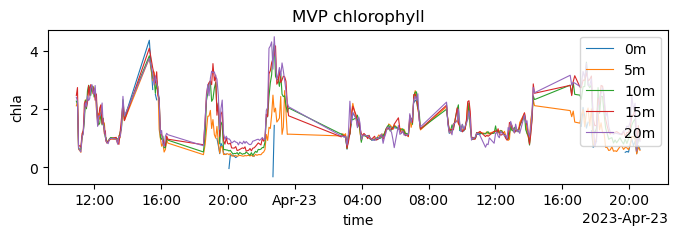

In [71]:
plt.figure(figsize=(8,2))

for i in range(5):
    mvp['chla'].sel(time=slice(times[0],
                               times[1])).sel(pressure=i*5,
                                              method='nearest').plot(label=f'{i*5}m',
                                                                    linewidth=0.8)
plt.legend()
plt.title('MVP chlorophyll')
plt.show()


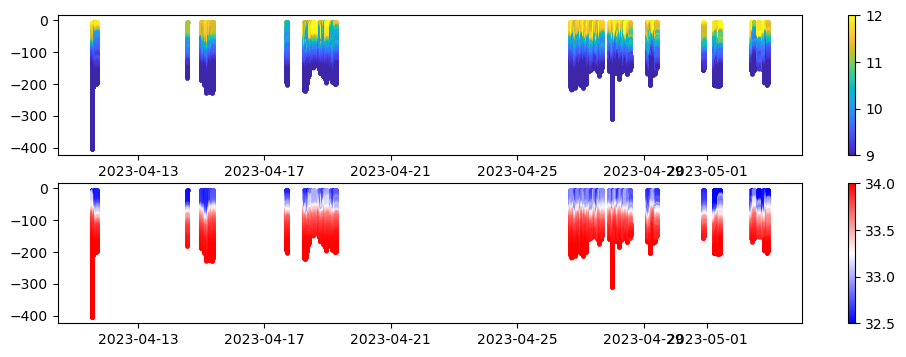

In [474]:
# EcoCTD
time_start = '2023-04-19'
time_end = '2023-04-22'
path = '/Users/elise/data/SMODE-data/'
files = sorted(glob(path+'ShipBoardEcoCTD/S_MODE_IOP2_SR2307_EcoCTD_L2*.nc'))[1:]
EcoCTD = xr.open_mfdataset(files[0])#, combine='by_coords', decode_times=False)
EcoCTD

fig,ax = plt.subplots(2,1,figsize=(12,4))
for file in files:
    ds = xr.open_dataset(file)

    pt=ax[0].scatter(ds.time,-ds.sea_pressure,c=ds.temperature, marker='s', s=2, vmin=9, vmax=12, cmap=parula)
    ps=ax[1].scatter(ds.time,-ds.sea_pressure,c=ds.practical_salinity, marker='s', s=2, vmin=32.5, vmax=34, cmap='bwr')
        

plt.colorbar(pt,ax=ax[0])
plt.colorbar(ps,ax=ax[1])

#for axis in ax:
    #axis.set_ylim(-105,0)
    #axis.set_xlim(pd.Timestamp('2023-04-10'),pd.Timestamp('2023-05-06'))
#    axis.set_xlim(pd.Timestamp('2023-04-19T12'), pd.Timestamp('2023-04-21'))
    #axis.set_xticks(rotation=20)
plt.show();

In [ ]:
# find at which depth the ACS is

depth_ACS = # ship measuring depth
depth_MVP_chl = 15 # single value at which we suspect no more NPQ

P_ACS = TSG['chlorophyll_ACS']
P_MVP = mvp['chla']